Dimensiones: (545, 13)
Columnas: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  

Tipos de datos:
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom      

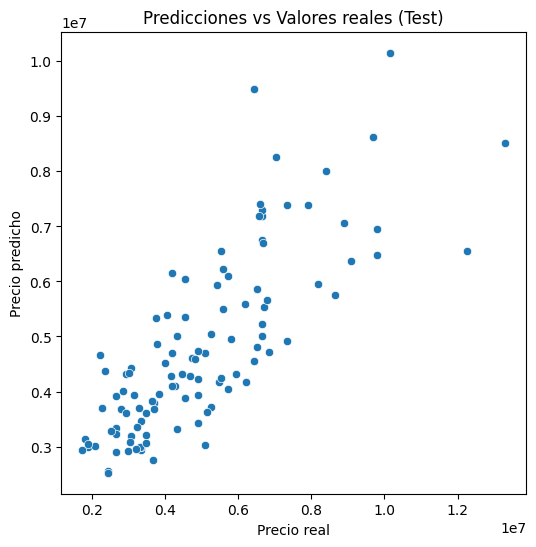

In [1]:
# =========================================
# 1. Importar librerías
# =========================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# 2. Cargar el dataset
# =========================================
ruta = r"C:\Users\Victor\Desktop\DIPLOMADO ANALYTICS  DATA\Housing.csv"
df = pd.read_csv(ruta)

print("Dimensiones:", df.shape)
print("Columnas:", df.columns.tolist())
print(df.head(3))

# =========================================
# 3. Revisar tipos de datos
# =========================================
print("\nTipos de datos:")
print(df.dtypes)

# =========================================
# 4. Separar variables predictoras y objetivo
# =========================================
X = df.drop('price', axis=1)
y = df['price']

# =========================================
# 5. Dividir en train y test (80/20)
# =========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =========================================
# 6. Identificar variables numéricas y categóricas
# =========================================
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print("\nNuméricas:", num_cols.tolist())
print("Categóricas:", cat_cols.tolist())

# =========================================
# 7. Crear transformadores
# =========================================
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(handle_unknown='ignore')

# Preprocesamiento combinado
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

# =========================================
# 8. Definir el modelo Random Forest
# =========================================
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Pipeline completo (preprocesamiento + modelo)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

# =========================================
# 9. Entrenar el modelo
# =========================================
pipeline.fit(X_train, y_train)

# =========================================
# 10. Predicciones
# =========================================
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

# =========================================
# 11. Evaluación (KPIs de regresión)
# =========================================
def eval_reg(y_true, y_pred, dataset_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n--- Métricas {dataset_name} ---")
    print(f"MAE:  {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²:   {r2:.4f}")

eval_reg(y_train, y_train_pred, "Entrenamiento")
eval_reg(y_test, y_test_pred, "Prueba")

# =========================================
# 12. Visualización de errores
# =========================================
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_test_pred)
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Predicciones vs Valores reales (Test)")
plt.show()
